# Acquisition smoke cases for all 16 provider paths

This operational notebook verifies the shared acquisition interfaces and visualizes a small, representative request plan. It is **not** a scientific-analysis notebook and it does not use parent-project data.

Safety defaults: the 14 registry providers run in `dry_run=True`; Tencent PMTiles and Mappls SDK capture are guarded by separate `False` switches. The default full-notebook run performs no network requests and writes no acquisition output.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "coverage_acquisition").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from inside the shared-dev repository.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "integrations" / "mappls_realview" / "src"))

from mappls_realview.bbox import BBox as MapplsBBox
from mappls_realview.bbox import tiles_for_bbox as mappls_tiles_for_bbox
from mappls_realview.sdk_capture import capture_sdk_bbox_async

from coverage_acquisition.geo import tile_range_for_bbox
from coverage_acquisition.models import BoundingBox, FetchAreaRequest
from coverage_acquisition.providers import PROVIDERS
from coverage_acquisition.runners import fetch_provider_coverage
from coverage_acquisition.tencent_pmtiles import (
    DEFAULT_TENCENT_PMTILES_URL,
    fetch_tencent_pmtiles_sv_coverage,
)

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Representative call cases

Each bounding box is intentionally small. `smoke_zoom` validates routing and tile planning; it is not automatically the recommended production level. Provisional production targets and review gates remain in `docs/provider_acquisition_status.md`.

In [2]:
CASES = [
    {
        "provider": "Google Street View",
        "registry_key": "svmap_google",
        "interface": "registry",
        "form": "raster",
        "region": "Amsterdam",
        "bbox": (4.895, 52.367, 4.905, 52.373),
        "smoke_zoom": 13,
        "status": "READY / LEVEL REVIEW",
    },
    {
        "provider": "Apple Look Around",
        "registry_key": "apple_lookaround",
        "interface": "registry",
        "form": "layered",
        "region": "Amsterdam",
        "bbox": (4.895, 52.367, 4.905, 52.373),
        "smoke_zoom": 12,
        "status": "ACCESS-GATED / LEVEL REVIEW",
    },
    {
        "provider": "KartaView",
        "registry_key": "kartaview",
        "interface": "registry",
        "form": "raster",
        "region": "Amsterdam",
        "bbox": (4.895, 52.367, 4.905, 52.373),
        "smoke_zoom": 13,
        "status": "PILOT ONLY / SCOPE REVIEW",
    },
    {
        "provider": "Panoramax",
        "registry_key": "panoramax",
        "interface": "registry",
        "form": "vector",
        "region": "Amsterdam",
        "bbox": (4.895, 52.367, 4.905, 52.373),
        "smoke_zoom": 13,
        "status": "COMPLETE BASELINE",
    },
    {
        "provider": "Mapillary",
        "registry_key": "mapillary",
        "interface": "registry",
        "form": "vector",
        "region": "Amsterdam",
        "bbox": (4.895, 52.367, 4.905, 52.373),
        "smoke_zoom": 13,
        "status": "READY / LEVEL REVIEW",
    },
    {
        "provider": "Baidu",
        "registry_key": "baidu",
        "interface": "registry",
        "form": "raster",
        "region": "Beijing",
        "bbox": (116.387, 39.902, 116.397, 39.908),
        "smoke_zoom": 13,
        "status": "READY / LEVEL REVIEW",
    },
    {
        "provider": "Naver",
        "registry_key": "naver",
        "interface": "registry",
        "form": "raster",
        "region": "Seoul",
        "bbox": (126.975, 37.565, 126.985, 37.571),
        "smoke_zoom": 14,
        "status": "COMPLETE BASELINE / LEVEL REVIEW",
    },
    {
        "provider": "Kakao",
        "registry_key": "kakao",
        "interface": "registry",
        "form": "raster",
        "region": "Seoul",
        "bbox": (126.975, 37.565, 126.985, 37.571),
        "smoke_zoom": 6,
        "status": "COMPLETE BASELINE / LEVEL REVIEW",
    },
    {
        "provider": "Streetview.vn",
        "registry_key": "streetview_vn",
        "interface": "registry",
        "form": "vector",
        "region": "Hanoi",
        "bbox": (105.830, 21.022, 105.840, 21.028),
        "smoke_zoom": 13,
        "status": "READY / LEVEL REVIEW",
    },
    {
        "provider": "MapJack",
        "registry_key": "mapjack",
        "interface": "registry",
        "form": "raster",
        "region": "Chiang Mai",
        "bbox": (98.980, 18.785, 98.990, 18.791),
        "smoke_zoom": 14,
        "status": "PILOT ONLY / LEVEL REVIEW",
    },
    {
        "provider": "Mapilio",
        "registry_key": "mapilio",
        "interface": "registry",
        "form": "vector",
        "region": "Istanbul",
        "bbox": (28.975, 41.015, 28.985, 41.021),
        "smoke_zoom": 14,
        "status": "READY / LEVEL REVIEW",
    },
    {
        "provider": "Mapy.com",
        "registry_key": "mapy",
        "interface": "registry",
        "form": "raster",
        "region": "Prague",
        "bbox": (14.415, 50.080, 14.425, 50.086),
        "smoke_zoom": 14,
        "status": "COMPLETE BASELINE / LEVEL REVIEW",
    },
    {
        "provider": "Barikoi ThirdEye360",
        "registry_key": "barikoi",
        "interface": "registry",
        "form": "vector",
        "region": "Dhaka",
        "bbox": (90.400, 23.810, 90.410, 23.816),
        "smoke_zoom": 14,
        "status": "PILOT ONLY / SCOPE REVIEW",
    },
    {
        "provider": "Yandex",
        "registry_key": "yandex",
        "interface": "registry",
        "form": "raster",
        "region": "Moscow",
        "bbox": (37.555, 55.740, 37.565, 55.746),
        "smoke_zoom": 13,
        "status": "READY / LEVEL REVIEW",
    },
    {
        "provider": "Tencent Street View",
        "registry_key": None,
        "interface": "tencent_pmtiles",
        "form": "vector",
        "region": "Beijing",
        "bbox": (116.387, 39.902, 116.397, 39.908),
        "smoke_zoom": 12,
        "status": "COMPLETE BASELINE",
    },
    {
        "provider": "Mappls RealView",
        "registry_key": None,
        "interface": "mappls_sdk",
        "form": "vector",
        "region": "Delhi",
        "bbox": (77.205, 28.610, 77.215, 28.616),
        "smoke_zoom": 13,
        "status": "ACCESS-GATED / LEVEL REVIEW",
    },
]

case_df = pd.DataFrame(CASES)
assert len(case_df) == 16 and case_df["provider"].is_unique
assert set(case_df["registry_key"].dropna()) == set(PROVIDERS)
display(case_df[["provider", "interface", "form", "region", "smoke_zoom", "status"]])

,provider,interface,form,region,smoke_zoom,status
0,Google Street View,registry,raster,Amsterdam,13,READY / LEVEL REVIEW
1,Apple Look Around,registry,layered,Amsterdam,12,ACCESS-GATED / LEVEL REVIEW
2,KartaView,registry,raster,Amsterdam,13,PILOT ONLY / SCOPE REVIEW
3,Panoramax,registry,vector,Amsterdam,13,COMPLETE BASELINE
4,Mapillary,registry,vector,Amsterdam,13,READY / LEVEL REVIEW
5,Baidu,registry,raster,Beijing,13,READY / LEVEL REVIEW
6,Naver,registry,raster,Seoul,14,COMPLETE BASELINE / LEVEL REVIEW
7,Kakao,registry,raster,Seoul,6,COMPLETE BASELINE / LEVEL REVIEW
8,Streetview.vn,registry,vector,Hanoi,13,READY / LEVEL REVIEW
9,MapJack,registry,raster,Chiang Mai,14,PILOT ONLY / LEVEL REVIEW


## Offline execution: 14 registry calls

The following cell calls the same public runner used by the CLI, but forces `dry_run=True`. It validates the provider key, coordinate grid, zoom-to-source routing and planned tile count without resolving frontend versions or requesting a tile.

In [3]:
OUTPUT_ROOT = PROJECT_ROOT / "local" / "notebook_smoke"  # ignored by Git
registry_results = {}
planned_rows = []

for case in CASES:
    key = case["registry_key"]
    if key is None:
        continue
    request = FetchAreaRequest(
        provider=key,
        bbox=BoundingBox.from_sequence(case["bbox"]),
        output_root=OUTPUT_ROOT,
        display_zoom=case["smoke_zoom"],
        dry_run=True,
    )
    result = fetch_provider_coverage(request)
    assert result["dry_run"] and len(result["jobs"]) == 1
    job = result["jobs"][0]
    registry_results[key] = result
    planned_rows.append(
        {
            "provider": case["provider"],
            "interface": case["interface"],
            "source_id": job["source"].id,
            "source_kind": job["source"].kind,
            "display_zoom": job["display_zoom"],
            "source_zoom": job["source_zoom"],
            "planned_tiles": job["source_tile_count"],
        }
    )

assert len(registry_results) == 14
plan_df = pd.DataFrame(planned_rows)
display(plan_df)

,provider,interface,source_id,source_kind,display_zoom,source_zoom,planned_tiles
0,Google Street View,registry,svmap_google_mts,raster,13,13,1
1,Apple Look Around,registry,apple_lookaround_cached_bluelines,vector_mvt,12,12,1
2,KartaView,registry,kartaview_sequence_tiles,raster,13,13,1
3,Panoramax,registry,panoramax_xyz_mvt,vector_mvt,13,13,1
4,Mapillary,registry,mapillary_mly1_public_vtp,vector_mvt,13,13,1
5,Baidu,registry,baidu_mapsv_tile,raster,13,13,1
6,Naver,registry,naver_streetview_overlay_png,raster,14,14,2
7,Kakao,registry,kakao_roadviewline,raster,6,6,2
8,Streetview.vn,registry,streetview_vn_snap_mvt,vector_mvt,13,13,1
9,MapJack,registry,mapjack_dots_r5,raster,14,14,2


## Offline planning for the two dedicated paths

Tencent uses a range-readable PMTiles archive rather than the registry runner. Mappls uses an authorization-gated browser SDK. Their local planning checks are appended here so the same 16-row visualization can be produced without contacting either service. Tencent's count is an approximate Web-Mercator planning count; the acquisition function applies the required WGS84-to-GCJ-02 conversion before selecting archive tiles.

In [4]:
tencent_case = next(case for case in CASES if case["interface"] == "tencent_pmtiles")
tencent_range = tile_range_for_bbox(
    BoundingBox.from_sequence(tencent_case["bbox"]),
    tencent_case["smoke_zoom"],
    "web_mercator",
)
planned_rows.append(
    {
        "provider": tencent_case["provider"],
        "interface": tencent_case["interface"],
        "source_id": "qq_map_lines_pmtiles_sv",
        "source_kind": "vector_mvt",
        "display_zoom": tencent_case["smoke_zoom"],
        "source_zoom": tencent_case["smoke_zoom"],
        "planned_tiles": tencent_range.count,
    }
)

mappls_case = next(case for case in CASES if case["interface"] == "mappls_sdk")
west, south, east, north = mappls_case["bbox"]
mappls_bbox = MapplsBBox(west, south, east, north).validate()
planned_rows.append(
    {
        "provider": mappls_case["provider"],
        "interface": mappls_case["interface"],
        "source_id": "mappls_realview_sdk",
        "source_kind": "vector_mvt",
        "display_zoom": mappls_case["smoke_zoom"],
        "source_zoom": mappls_case["smoke_zoom"],
        "planned_tiles": len(mappls_tiles_for_bbox(mappls_bbox, mappls_case["smoke_zoom"])),
    }
)

plan_df = pd.DataFrame(planned_rows).sort_values("provider").reset_index(drop=True)
assert len(plan_df) == 16 and plan_df["provider"].is_unique
display(plan_df)

,provider,interface,source_id,source_kind,display_zoom,source_zoom,planned_tiles
0,Apple Look Around,registry,apple_lookaround_cached_bluelines,vector_mvt,12,12,1
1,Baidu,registry,baidu_mapsv_tile,raster,13,13,1
2,Barikoi ThirdEye360,registry,barikoi_thirdeye360_mvt,vector_mvt,14,14,1
3,Google Street View,registry,svmap_google_mts,raster,13,13,1
4,Kakao,registry,kakao_roadviewline,raster,6,6,2
5,KartaView,registry,kartaview_sequence_tiles,raster,13,13,1
6,MapJack,registry,mapjack_dots_r5,raster,14,14,2
7,Mapilio,registry,mapilio_map_roads_line_vtp,vector_mvt,14,14,2
8,Mapillary,registry,mapillary_mly1_public_vtp,vector_mvt,13,13,1
9,Mappls RealView,mappls_sdk,mappls_realview_sdk,vector_mvt,13,13,4


## Visual check of representative requests

The left panel checks that the sample cases fall in the expected service regions. The right panel exposes unexpectedly large smoke requests or zoom/grid-routing mistakes before any network acquisition.

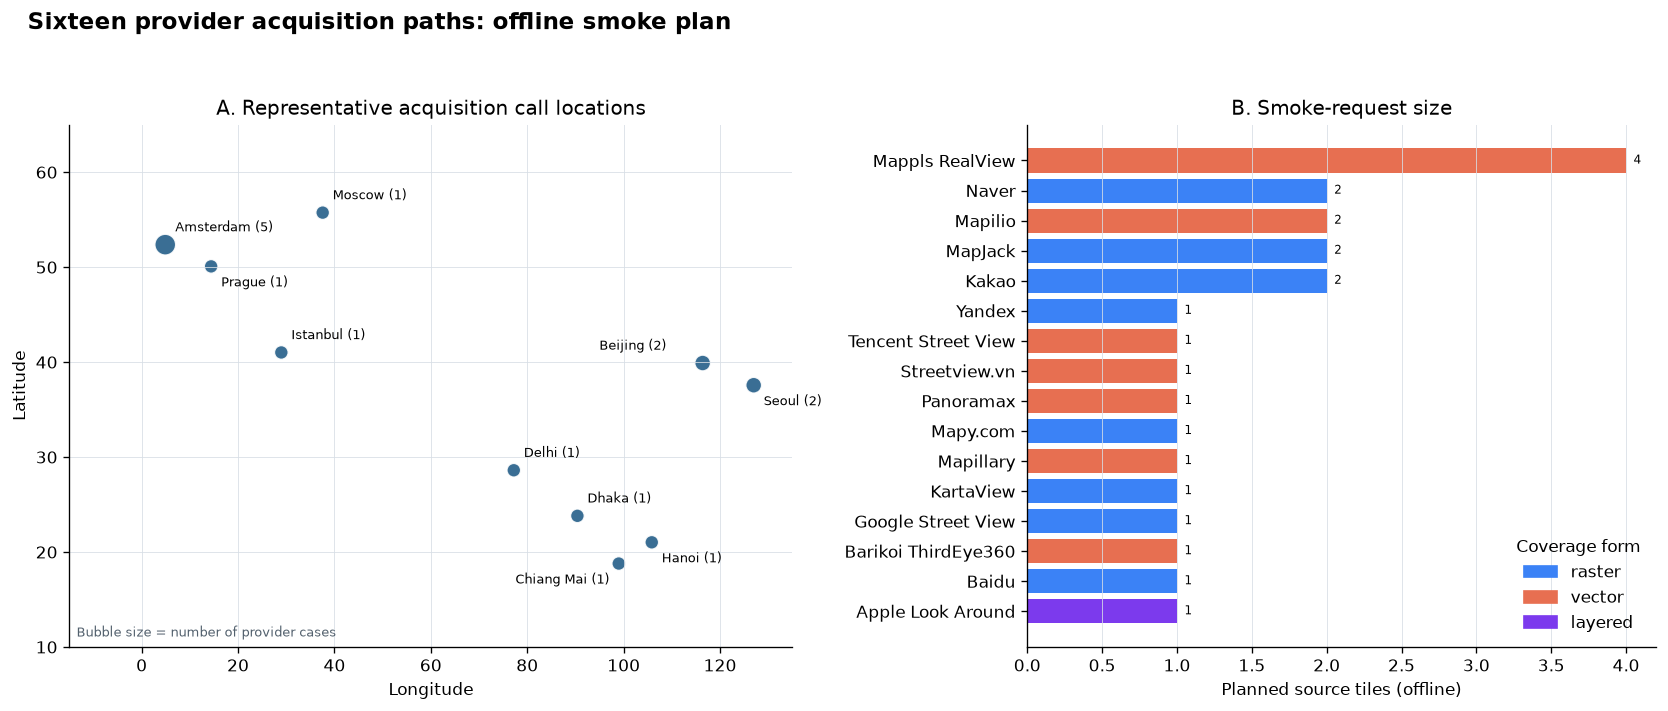

In [5]:
plot_cases = case_df.copy()
plot_cases["lon"] = plot_cases["bbox"].map(lambda b: (b[0] + b[2]) / 2)
plot_cases["lat"] = plot_cases["bbox"].map(lambda b: (b[1] + b[3]) / 2)
plot_cases["planned_tiles"] = plot_cases["provider"].map(plan_df.set_index("provider")["planned_tiles"])
colors = {"raster": "#3B82F6", "vector": "#E76F51", "layered": "#7C3AED"}

fig, (ax_map, ax_bar) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.15, 1]})
location_data = plot_cases.groupby(["region", "lon", "lat"], as_index=False).agg(provider_count=("provider", "size"))
label_offsets = {
    "Amsterdam": (6, 8),
    "Prague": (6, -12),
    "Moscow": (6, 8),
    "Seoul": (6, -12),
    "Beijing": (-62, 8),
    "Hanoi": (6, -12),
    "Chiang Mai": (-62, -12),
    "Dhaka": (6, 8),
    "Delhi": (6, 8),
    "Istanbul": (6, 8),
}
ax_map.scatter(
    location_data["lon"],
    location_data["lat"],
    s=45 + 22 * location_data["provider_count"],
    color="#1F5A85",
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8,
)
for _, row in location_data.iterrows():
    label = f"{row['region']} ({int(row['provider_count'])})"
    ax_map.annotate(
        label, (row["lon"], row["lat"]), xytext=label_offsets[row["region"]], textcoords="offset points", fontsize=8
    )
ax_map.set(
    xlim=(-15, 135),
    ylim=(10, 65),
    xlabel="Longitude",
    ylabel="Latitude",
    title="A. Representative acquisition call locations",
)
ax_map.grid(color="#D7DEE5", linewidth=0.6, alpha=0.8)
ax_map.text(
    0.01, 0.02, "Bubble size = number of provider cases", transform=ax_map.transAxes, fontsize=8, color="#52606D"
)

bar_data = plot_cases.sort_values(["planned_tiles", "provider"])
ax_bar.barh(bar_data["provider"], bar_data["planned_tiles"], color=bar_data["form"].map(colors))
for index, value in enumerate(bar_data["planned_tiles"]):
    ax_bar.text(value + 0.05, index, str(int(value)), va="center", fontsize=7)
ax_bar.set(xlabel="Planned source tiles (offline)", title="B. Smoke-request size")
ax_bar.grid(axis="x", color="#D7DEE5", linewidth=0.6, alpha=0.8)
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color, label=form) for form, color in colors.items()]
ax_bar.legend(handles=legend_handles, title="Coverage form", frameon=False, loc="lower right")
fig.suptitle(
    "Sixteen provider acquisition paths: offline smoke plan", fontsize=14, fontweight="bold", x=0.02, ha="left"
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## Guarded real acquisition calls

Leave all switches disabled for routine notebook testing. Before enabling a provider, review authorization and terms, use a bounded case, and provide any required credentials through environment variables or ignored local configuration. MapJack in particular requires low request rates; the generic runner does not add throttling.

In [6]:
RUN_REGISTRY_NETWORK: set[str] = set()  # Example: {'panoramax'}; never enable all blindly.
RUN_TENCENT_PMTILES = False
RUN_MAPPLS_SDK = False

network_results = {}
for key in sorted(RUN_REGISTRY_NETWORK):
    case = next(item for item in CASES if item["registry_key"] == key)
    network_results[key] = fetch_provider_coverage(
        FetchAreaRequest(
            provider=key,
            bbox=BoundingBox.from_sequence(case["bbox"]),
            output_root=OUTPUT_ROOT,
            display_zoom=case["smoke_zoom"],
            dry_run=False,
            access_token=os.getenv("MAPILLARY_ACCESS_TOKEN") if key == "mapillary" else None,
            stop_on_error=False if key == "mapilio" else True,
        )
    )

tencent_result = None
if RUN_TENCENT_PMTILES:
    tencent_result = fetch_tencent_pmtiles_sv_coverage(
        BoundingBox.from_sequence(tencent_case["bbox"]),
        output_root=OUTPUT_ROOT,
        cache_dir=PROJECT_ROOT / "local" / "tencent_pmtiles_cache",
        source_url=os.getenv("TENCENT_PMTILES_URL", DEFAULT_TENCENT_PMTILES_URL),
        source_zoom=tencent_case["smoke_zoom"],
    )

mappls_result = None
if RUN_MAPPLS_SDK:
    mappls_result = await capture_sdk_bbox_async(
        web_dir=PROJECT_ROOT / "integrations" / "mappls_realview" / "web",
        bbox=mappls_bbox,
        zoom=mappls_case["smoke_zoom"],
        out_dir=OUTPUT_ROOT / "mappls_realview",
        output_mode="production",
        headless=True,
    )

guarded_summary = (
    f"Guarded calls executed: registry={len(network_results)}, "
    f"Tencent={tencent_result is not None}, "
    f"Mappls={mappls_result is not None}"
)
print(guarded_summary)

Guarded calls executed: registry=0, Tencent=False, Mappls=False


## Expected offline result

A successful default run reports 14 dry-run registry results, a 16-row unique provider plan, two visual audit panels and zero guarded network calls. This is a smoke test of interfaces and request planning—not proof that mutable third-party endpoints are currently reachable.